In [1]:
#Import Librarys 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import the File

try:
    df = pd.read_csv("Data_Sheet/ola_driver.csv")
except FileNotFoundError as e:
    print(f"Error {e}.")
except Exception as e1:
    print(f"Error {e1}.")

In [3]:
"""
# Define Problem Statement and Perform Exploratory Data Analysis (10 points)
-> Definition of Problem:- Understand the challenge of driver attrition and its impact on Ola.

# Data Exploration:
-> Check data shape, data types, and convert categorical attributes if necessary.
-> Detect missing values and prepare for simple imputation.
-> Perform statistical summary to understand data distribution.
"""

'\n# Define Problem Statement and Perform Exploratory Data Analysis (10 points)\n-> Definition of Problem:- Understand the challenge of driver attrition and its impact on Ola.\n\n# Data Exploration:\n-> Check data shape, data types, and convert categorical attributes if necessary.\n-> Detect missing values and prepare for simple imputation.\n-> Perform statistical summary to understand data distribution.\n'

In [4]:
print(f"Into the shape there is total {df.shape[0]} rows , and {df.shape[1]} number of columns is there.\n")

Into the shape there is total 19104 rows , and 14 number of columns is there.



In [5]:
print("Lets see the Data types of the all columns.\n",df.dtypes)

Lets see the Data types of the all columns.
 Unnamed: 0                int64
MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object


In [6]:
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [19]:
df.describe()

,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,1415.591133,34.666300,0.417609,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,810.705321,6.248026,0.493178,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [7]:
#Delete Unwanted Columns

df.drop("Unnamed: 0",axis=1,inplace=True)


In [13]:
df["Age"] = pd.to_numeric(df["Age"],errors="coerce")
df['Age'] = df['Age'].fillna(df['Age'].mean())
df["Age"] = df["Age"].astype(int)

df["Gender"] = pd.to_numeric(df["Gender"],errors="coerce")
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [34]:
df.isna().sum()

MMM-YY                  0
Driver_ID               0
Age                     0
Gender                  0
City                    0
Education_Level         0
Income                  0
Dateofjoining           0
Joining Designation     0
Grade                   0
Total Business Value    0
Quarterly Rating        0
Churn                   0
dtype: int64

In [24]:
#Make the Churn Column.

df["Churn"] = df["LastWorkingDate"].notnull().astype(int)
df.drop("LastWorkingDate",axis=1,inplace=True)

In [66]:
#Saperate the Numaric and categorical columns
numaric_feture = []
categorical_feture = []

for i in df.columns:
    if df[i].dtype == "object":
        categorical_feture.append(i)
    else:
        numaric_feture.append(i)
print("Numaric : ",numaric_feture)
print("Categorical  : ",categorical_feture)

Numaric :  ['Driver_ID', 'Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating', 'Churn']
Categorical  :  ['MMM-YY', 'City', 'Dateofjoining']


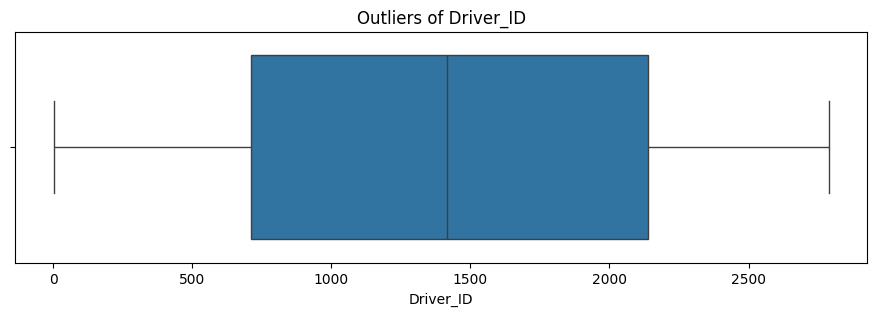

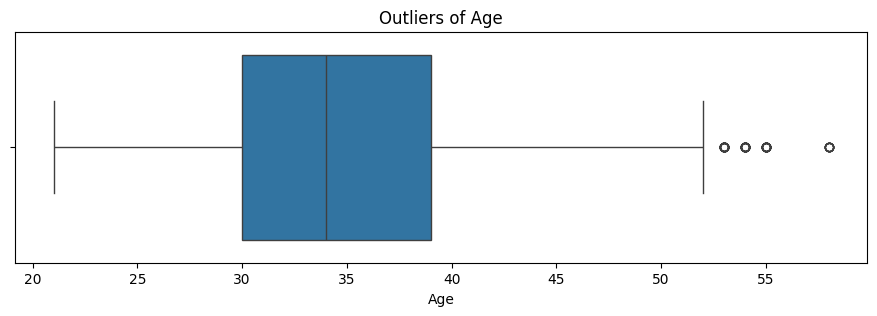

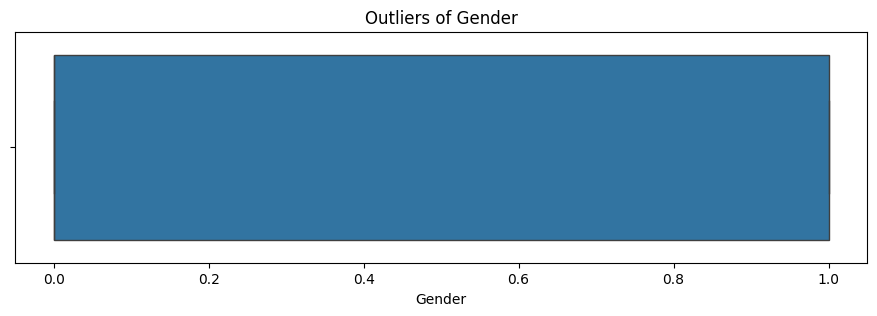

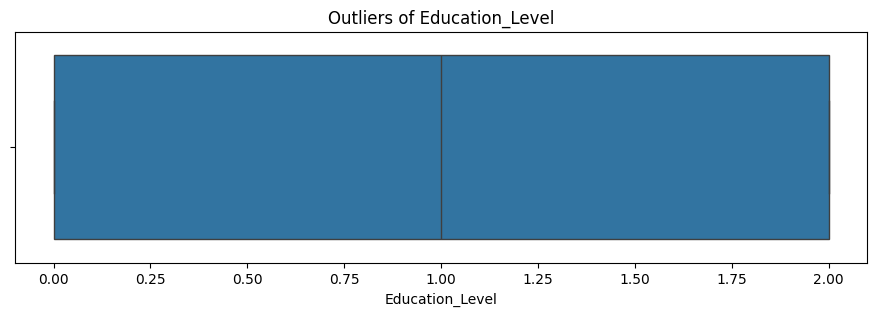

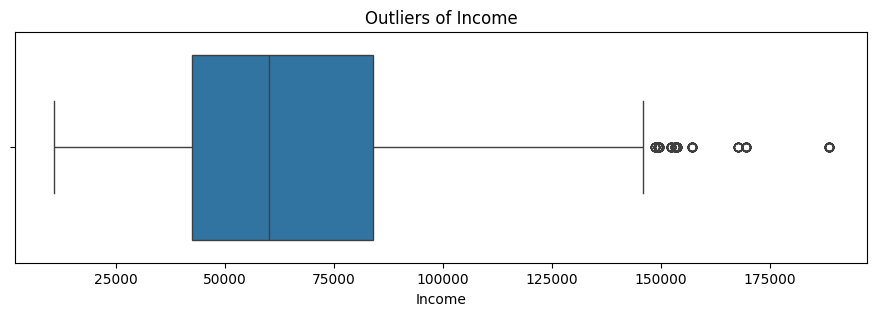

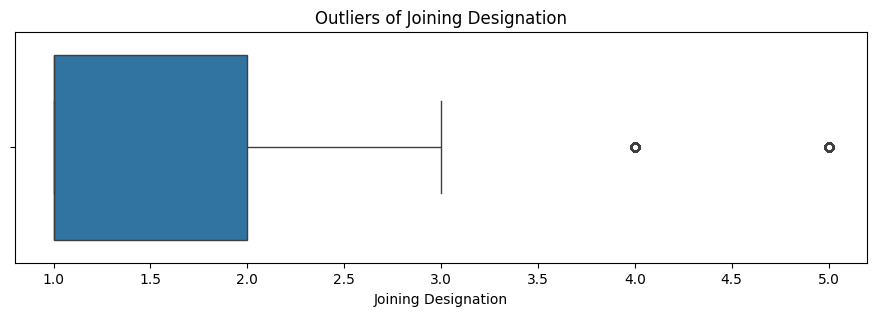

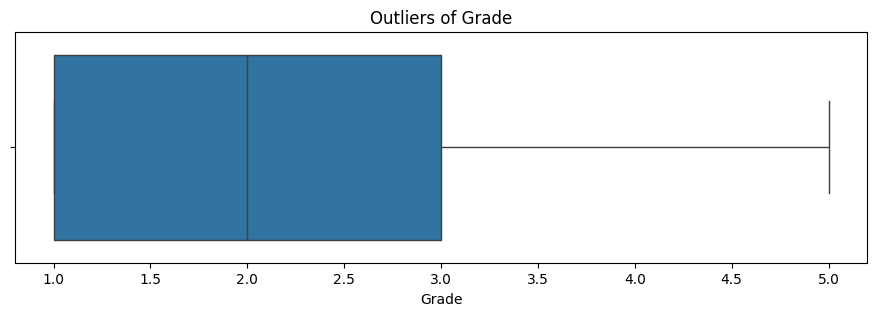

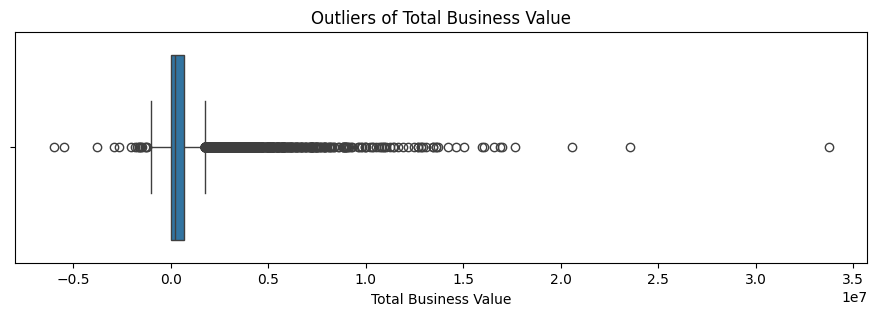

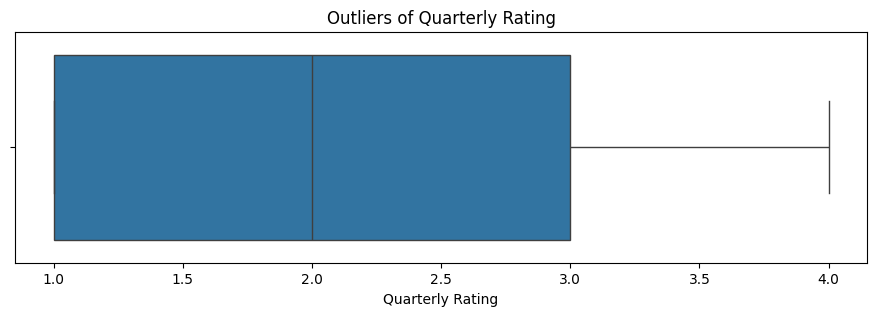

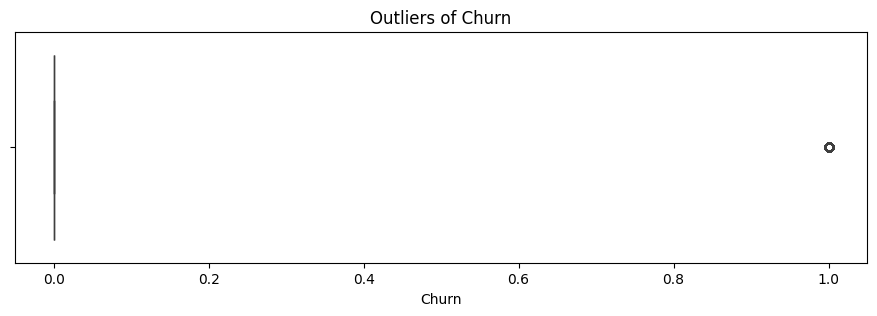

In [69]:
# #Lets see there is have outliers or not.

for i in numaric_feture:
    plt.figure(figsize=(11,3))
    sns.boxplot(x = df[i])
    plt.title(f"Outliers of {i}")
    plt.show()

In [12]:
df.dtypes

MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object